# Plot

In [8]:
import os
import pickle
from pathlib import Path

import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "pdf.fonttype": 42,            # editable text in Adobe Illustrator
    "ps.fonttype": 42,             # editable text in Adobe Illustrator

    "figure.dpi": 100,
    "savefig.dpi": 600,              # very high-res when saving
    "savefig.format": "pdf",         # vector output preferred

    # # Fonts
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"],  # IEEE default

    # # Axes
    "axes.linewidth": 1.5,

    # Lines
    "lines.linewidth": 2.0,
})


# # G1 29dof
DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/g1_29dof_soft_adaptation"
# data_dir = DATA_ROOT / "2026-03-24_19-30-46" / "logs"
data_dir = DATA_ROOT / "2026-03-25_01-08-38" / "logs"

In [9]:
def quat_to_yaw(quat):
    """Extract yaw from quaternion [w, x, y, z]"""
    w, x, y, z = quat[..., 0], quat[..., 1], quat[..., 2], quat[..., 3]
    yaw = np.arctan2(2.0*(w*z + x*y), 1.0 - 2.0*(y*y + z*z))
    return yaw

In [10]:
base_pos = slice(0, 3)
yaw_quat_idx = slice(3, 7)  # w, x, y, z
base_lin_vel_idx = slice(7, 10)   # x, y, z
base_ang_vel_idx = slice(10, 13)   # roll, pitch, yaw
velocity_commands_idx = slice(13, 16)  # x, y, yaw
heading_commands_idx = slice(16, 20)


# privileged
priv_base_lin_vel_idx = slice(0, 3)
foot_height_idx = slice(3, 5)

rigid_contact_idx = slice(5, 7)
rigid_contact_force_idx = slice(7, 13)
rigid_air_time_idx = slice(13, 15)

soft_contact_idx = slice(15, 17)
soft_contact_force_idx = slice(17, 23)
soft_air_time_idx = slice(23, 25)

material_idx = slice(25, 28)

# log privileged
contact_idx = slice(5, 7)
contact_force_idx = slice(7, 13)
foot_air_time_idx = slice(13, 15)
material_prop_idx = slice(15, None)

In [11]:
data_path = data_dir / "rl_play"

policy_obs_path = (data_path / "obs/obs.pkl").as_posix()
privileged_obs_path = (data_path / "privileged/privileged.pkl").as_posix()
log_privileged_obs_path = (data_path / "log_privileged/log_privileged.pkl").as_posix()

with open(policy_obs_path, "rb") as f:
    policy_obs = pickle.load(f)
    policy_obs = np.array(policy_obs).squeeze(0)

with open(privileged_obs_path, "rb") as f:
    privileged_obs = pickle.load(f)
    privileged_obs = np.array(privileged_obs).squeeze(0)

with open(log_privileged_obs_path, "rb") as f:
    log_privileged_obs = pickle.load(f)
    log_privileged_obs = np.array(log_privileged_obs).squeeze(0)

print(f"policy_obs shape: {policy_obs.shape}")
print(f"privileged obs shape: {privileged_obs.shape}")
print(f"log privileged obs shape: {log_privileged_obs.shape}")

data = {}
data["yaw_quat"] = policy_obs[:, :, yaw_quat_idx]
data["base_lin_vel"] = policy_obs[:, :, base_lin_vel_idx]
data["base_ang_vel"] = policy_obs[:, :, base_ang_vel_idx]
data["velocity_commands"] = policy_obs[:, :, velocity_commands_idx]
data["heading_commands"] = policy_obs[:, :, heading_commands_idx]

privileged_data = {}
privileged_data["base_lin_vel"] = privileged_obs[:, :, priv_base_lin_vel_idx]
privileged_data["foot_height"] = privileged_obs[:, :, foot_height_idx]

privileged_data["rigid_contact"] = privileged_obs[:, :, rigid_contact_idx]
privileged_data["rigid_contact_force"] = privileged_obs[:, :, rigid_contact_force_idx]
privileged_data["rigid_air_time"] = privileged_obs[:, :, rigid_air_time_idx]

privileged_data["soft_contact"] = privileged_obs[:, :, soft_contact_idx]
privileged_data["soft_contact_force"] = privileged_obs[:, :, soft_contact_force_idx]
privileged_data["soft_air_time"] = privileged_obs[:, :, soft_air_time_idx]

privileged_data["material"] = privileged_obs[:, :, material_idx]


log_privileged_data = {}
log_privileged_data["base_lin_vel"] = log_privileged_obs[:, :, priv_base_lin_vel_idx]
log_privileged_data["foot_height"] = log_privileged_obs[:, :, foot_height_idx]
log_privileged_data["contact"] = log_privileged_obs[:, :, contact_idx]
log_privileged_data["contact_force"] = log_privileged_obs[:, :, contact_force_idx]
log_privileged_data["foot_air_time"] = log_privileged_obs[:, :, foot_air_time_idx]
log_privileged_data["material_prop"] = log_privileged_obs[:, :, material_prop_idx]

policy_obs shape: (1, 1000, 26)
privileged obs shape: (1, 1000, 280)
log privileged obs shape: (1, 1000, 18)


In [12]:
t_range = slice(200, 900)

# vx_err = np.abs(data["base_lin_vel"][:, t_range, 0] - data["velocity_commands"][:, t_range, 0])
# vx_err_mean = vx_err.mean()
# vx_err_std = vx_err.std()

# wz_err = np.abs(data["base_ang_vel"][:, t_range, 2] - data["velocity_commands"][:, t_range, 2])
# wz_err_mean = wz_err.mean()
# wz_err_std = wz_err.std()

# print(f"VX error mean: {vx_err_mean:.4f}, std: {vx_err_std:.4f}")
# print(f"WZ error mean: {wz_err_mean:.4f}, std: {wz_err_std:.4f}")

### Plot

### privileged info plot

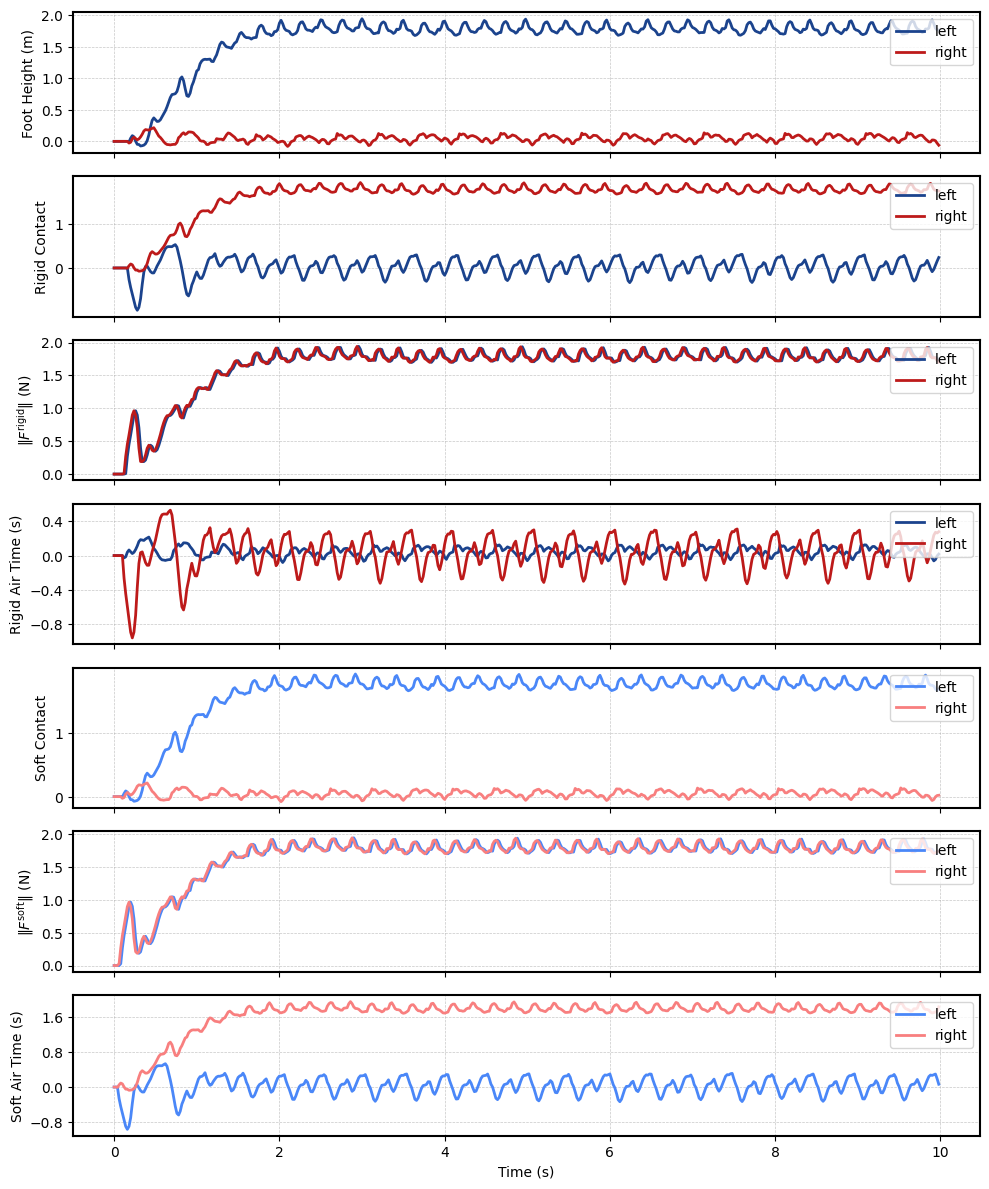

In [13]:
ENV_ID = 0
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 500)

colors_left  = ["#1B438D", "#4A87F8"]
colors_right = ["#BD1A1A", "#F87F7F"]

fig, axs = plt.subplots(7, 1, figsize=(10, 12), sharex=True)

def foot_force_norm(force_flat):
    return np.linalg.norm(force_flat.reshape(force_flat.shape[0], 2, 3), axis=-1)

foot_height         = privileged_data["foot_height"][ENV_ID, t_range]
rigid_contact       = privileged_data["rigid_contact"][ENV_ID, t_range]
rigid_force_norm    = foot_force_norm(privileged_data["rigid_contact_force"][ENV_ID, t_range])
rigid_air_time      = privileged_data["rigid_air_time"][ENV_ID, t_range]
soft_contact        = privileged_data["soft_contact"][ENV_ID, t_range]
soft_force_norm     = foot_force_norm(privileged_data["soft_contact_force"][ENV_ID, t_range])
soft_air_time       = privileged_data["soft_air_time"][ENV_ID, t_range]

t_plot = t[t_range]

# ── 0: foot height ───────────────────────────────────────────────────────────
ax = axs[0]
ax.plot(t_plot, foot_height[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, foot_height[:, 1], label="right", color=colors_right[0])
ax.set_ylabel(r"Foot Height (m)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 1: rigid contact ─────────────────────────────────────────────────────────
ax = axs[1]
ax.plot(t_plot, rigid_contact[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, rigid_contact[:, 1], label="right", color=colors_right[0])
ax.set_ylabel("Rigid Contact")
ax.set_yticks([0, 1])
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 2: norm of rigid contact force ───────────────────────────────────────────
ax = axs[2]
ax.plot(t_plot, rigid_force_norm[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, rigid_force_norm[:, 1], label="right", color=colors_right[0])
ax.set_ylabel(r"$\|F^\mathrm{rigid}\|$ (N)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 3: rigid air time ────────────────────────────────────────────────────────
ax = axs[3]
ax.plot(t_plot, rigid_air_time[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, rigid_air_time[:, 1], label="right", color=colors_right[0])
ax.set_ylabel("Rigid Air Time (s)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 4: soft contact ──────────────────────────────────────────────────────────
ax = axs[4]
ax.plot(t_plot, soft_contact[:, 0], label="left",  color=colors_left[1])
ax.plot(t_plot, soft_contact[:, 1], label="right", color=colors_right[1])
ax.set_ylabel("Soft Contact")
ax.set_yticks([0, 1])
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 5: norm of soft contact force ────────────────────────────────────────────
ax = axs[5]
ax.plot(t_plot, soft_force_norm[:, 0], label="left",  color=colors_left[1])
ax.plot(t_plot, soft_force_norm[:, 1], label="right", color=colors_right[1])
ax.set_ylabel(r"$\|F^\mathrm{soft}\|$ (N)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 6: soft air time ─────────────────────────────────────────────────────────
ax = axs[6]
ax.plot(t_plot, soft_air_time[:, 0], label="left",  color=colors_left[1])
ax.plot(t_plot, soft_air_time[:, 1], label="right", color=colors_right[1])
ax.set_ylabel("Soft Air Time (s)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

axs[-1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()


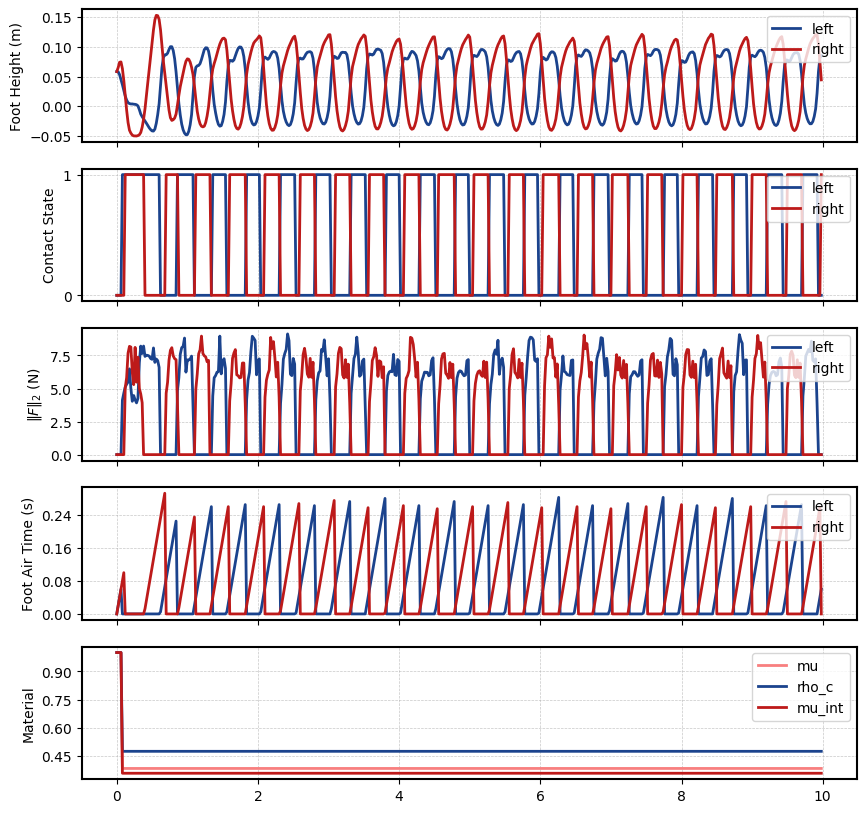

In [14]:
ENV_ID = 0
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 500)

colors_left  = ["#1B438D", "#4A87F8"]
colors_right = ["#BD1A1A", "#F87F7F"]

fig, axs = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

def foot_force_norm(force_flat):
    return np.linalg.norm(force_flat.reshape(force_flat.shape[0], 2, 3), axis=-1)

foot_height         = log_privileged_data["foot_height"][ENV_ID, t_range]
contact       = log_privileged_data["contact"][ENV_ID, t_range]
force_norm    = foot_force_norm(log_privileged_data["contact_force"][ENV_ID, t_range])
foot_air_time      = log_privileged_data["foot_air_time"][ENV_ID, t_range]
material_prop = log_privileged_data["material_prop"][ENV_ID, t_range]


t_plot = t[t_range]

# ── 0: foot height ───────────────────────────────────────────────────────────
ax = axs[0]
ax.plot(t_plot, foot_height[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, foot_height[:, 1], label="right", color=colors_right[0])
ax.set_ylabel(r"Foot Height (m)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 1: rigid contact ─────────────────────────────────────────────────────────
ax = axs[1]
ax.plot(t_plot, contact[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, contact[:, 1], label="right", color=colors_right[0])
ax.set_ylabel("Contact State")
ax.set_yticks([0, 1])
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 2: norm of rigid contact force ───────────────────────────────────────────
ax = axs[2]
ax.plot(t_plot, force_norm[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, force_norm[:, 1], label="right", color=colors_right[0])
ax.set_ylabel(r"$\|F\|_2$ (N)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 3: rigid air time ────────────────────────────────────────────────────────
ax = axs[3]
ax.plot(t_plot, foot_air_time[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, foot_air_time[:, 1], label="right", color=colors_right[0])
ax.set_ylabel("Foot Air Time (s)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


ax = axs[4]
ax.plot(t_plot, material_prop[:, 0], label="mu",  color=colors_right[1])
ax.plot(t_plot, material_prop[:, 1], label="rho_c",  color=colors_left[0])
ax.plot(t_plot, material_prop[:, 2], label="mu_int", color=colors_right[0])
ax.set_ylabel("Material")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

#### joint pos

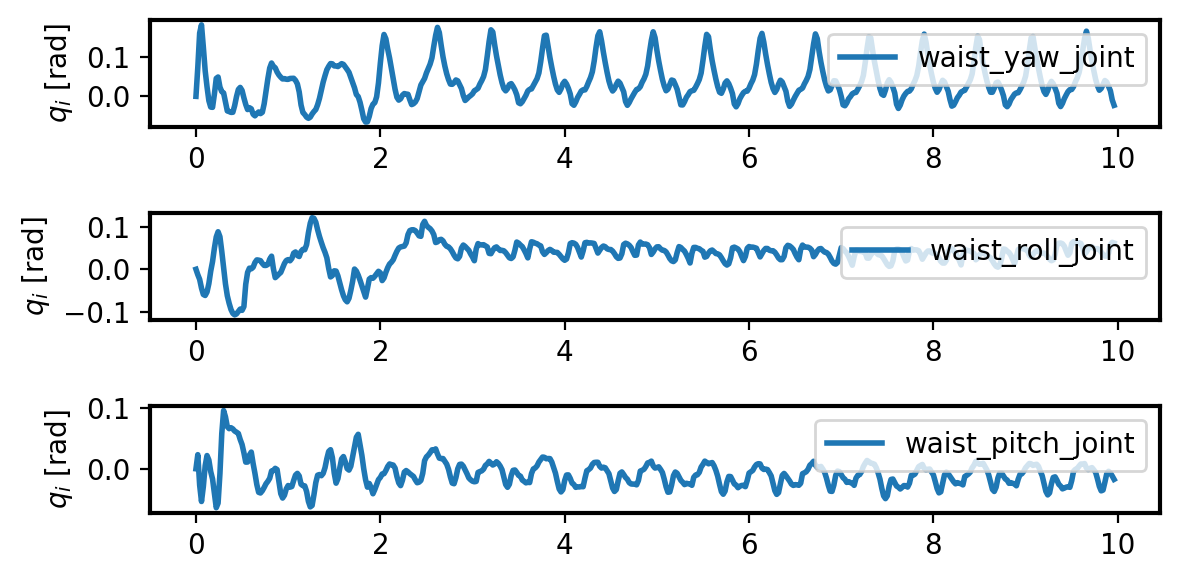

In [ ]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 499)
colors = ["#1B438D", "#3C7FFD", "#BD1A1A"]


fig, axs = plt.subplots(3, 1, figsize=(6, 3))
joint_names = [
    "waist_yaw_joint", 
    "waist_roll_joint", 
    "waist_pitch_joint", 
]

# vx
for i in range(len(joint_names)):
    ax = axs[i]
    ax.plot(t[t_range], data["joint_pos"][ENV_ID, t_range, i], label=joint_names[i])
    ax.legend(loc="upper right")
    ax.set_ylabel(r'$q_i$ [rad]')


fig.tight_layout()
plt.show()

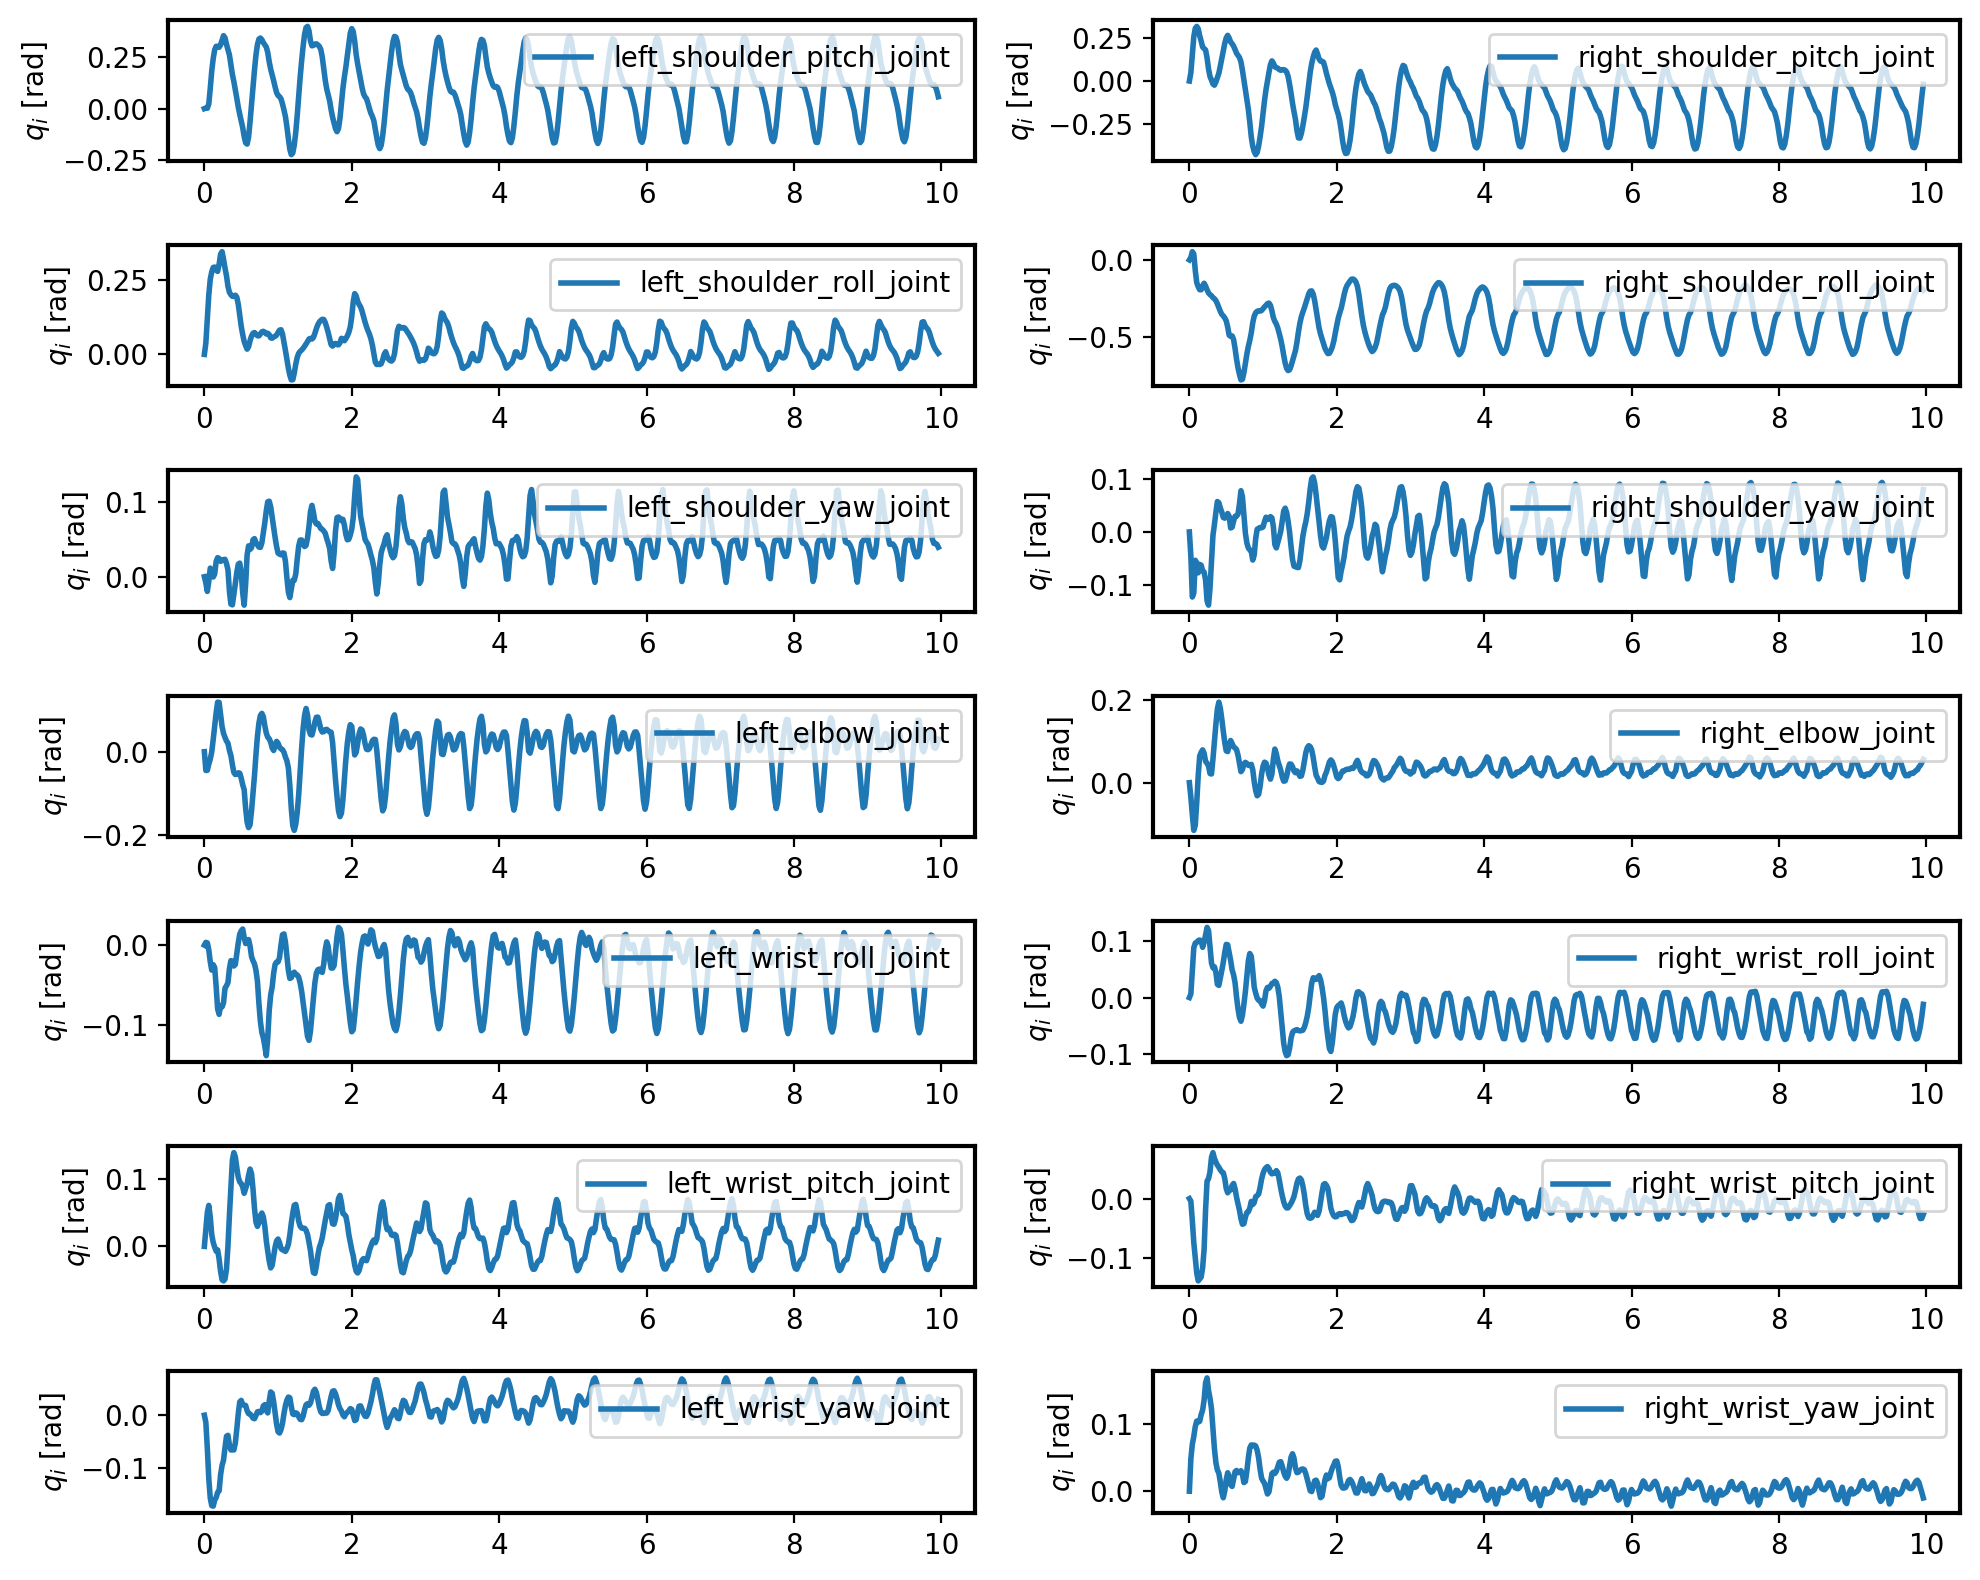

In [ ]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 499)
colors = ["#1B438D", "#3C7FFD", "#BD1A1A"]


fig, axs = plt.subplots(7, 2, figsize=(10, 8))
joint_names = [
    # left arm
    "left_shoulder_pitch_joint", 
    "left_shoulder_roll_joint", 
    "left_shoulder_yaw_joint", 
    "left_elbow_joint", 

    "left_wrist_roll_joint", 
    "left_wrist_pitch_joint", 
    "left_wrist_yaw_joint", 

    # right arm
    "right_shoulder_pitch_joint", 
    "right_shoulder_roll_joint", 
    "right_shoulder_yaw_joint", 
    "right_elbow_joint", 

    "right_wrist_roll_joint", 
    "right_wrist_pitch_joint", 
    "right_wrist_yaw_joint", 
]

# vx
for i in range(len(joint_names)):
    if i < 7:
        ax = axs[i, 0]
    else:
        ax = axs[i - 7, 1]
    ax.plot(t[t_range], data["joint_pos"][ENV_ID, t_range, i+3], label=joint_names[i])
    ax.legend(loc="upper right")
    ax.set_ylabel(r'$q_i$ [rad]')


fig.tight_layout()
plt.show()

#### command tracking

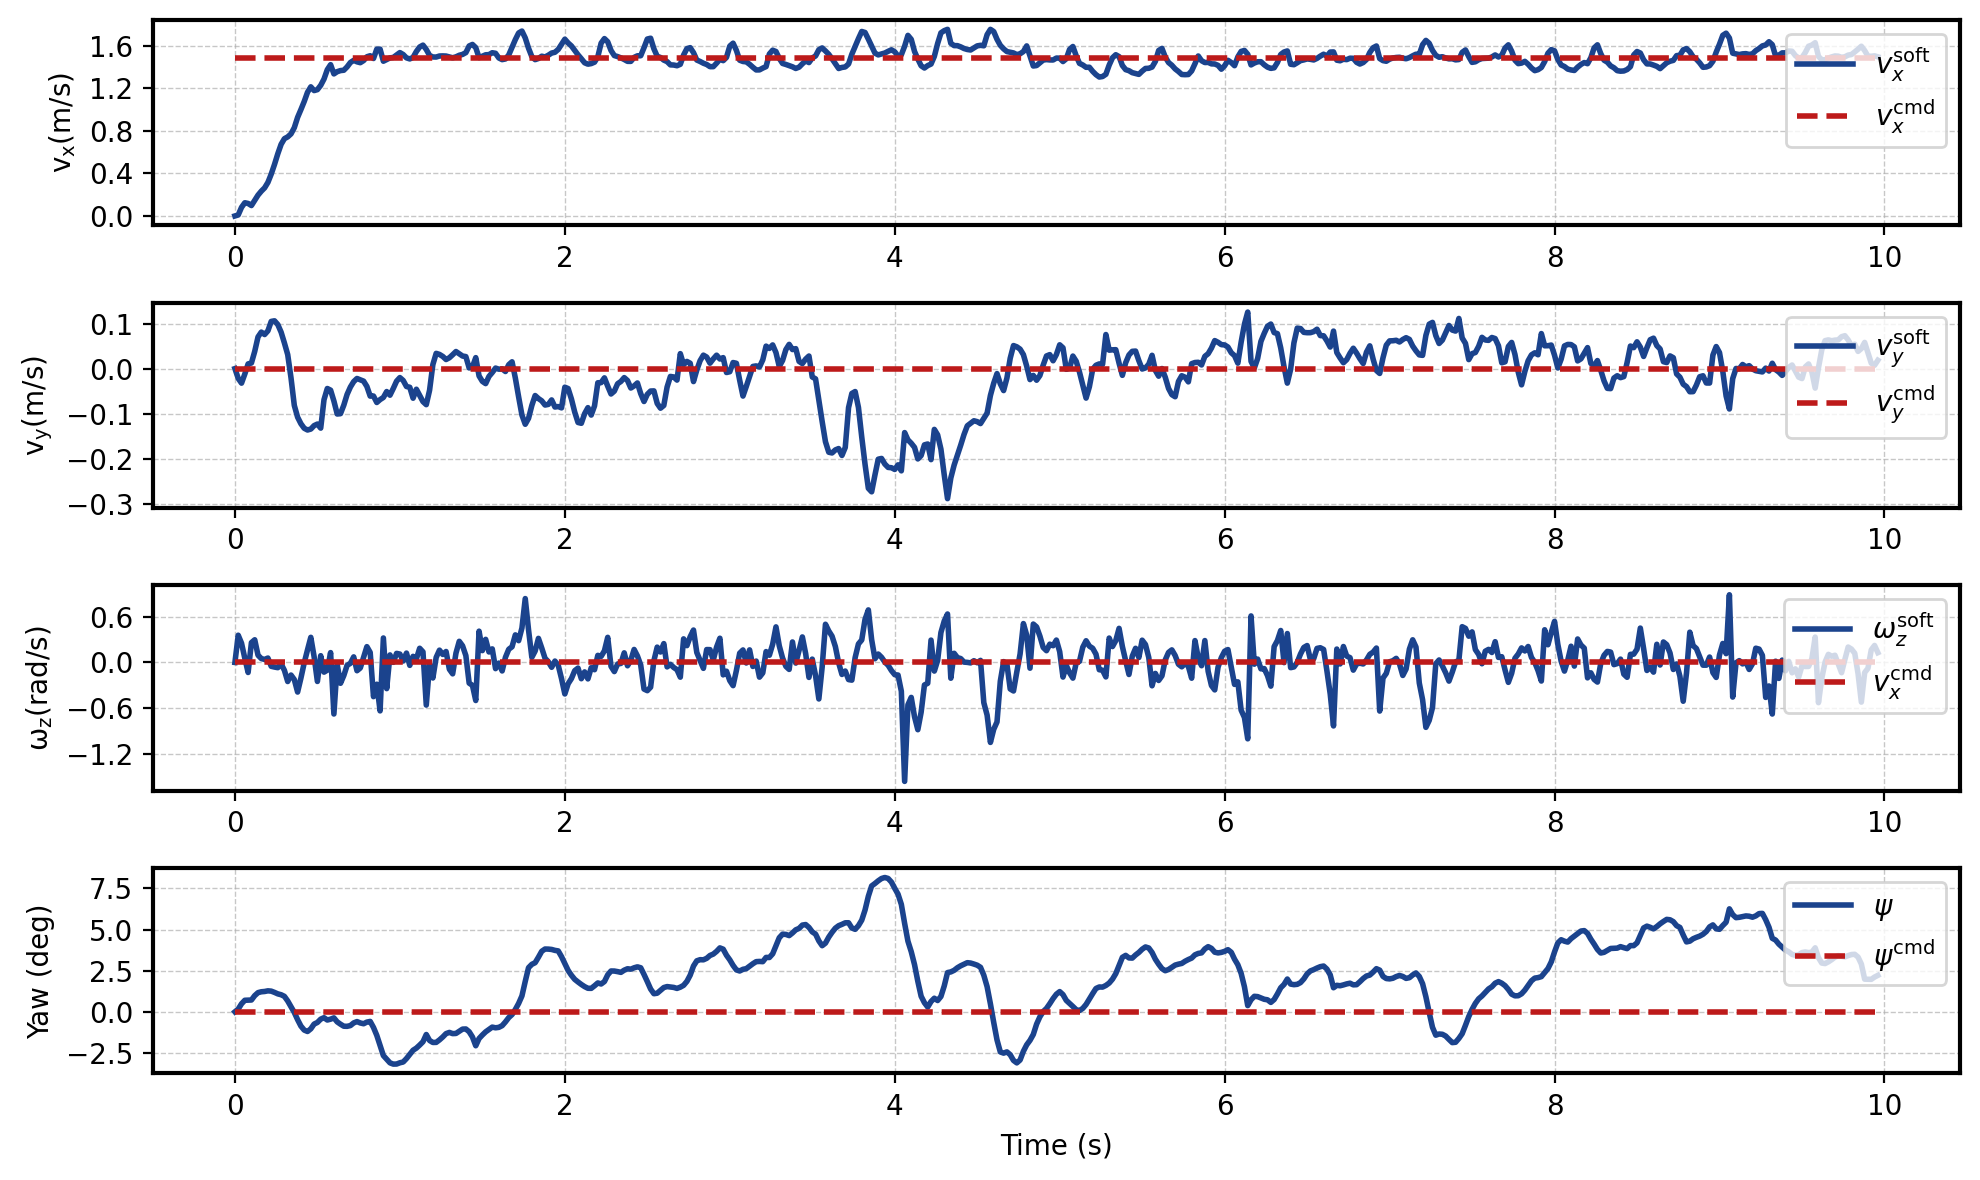

In [97]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 499)
colors = ["#1B438D", "#3C7FFD", "#BD1A1A"]


fig, axs = plt.subplots(4, 1, figsize=(10, 6))

# vx
ax = axs[0]
ax.plot(t[t_range], data["base_lin_vel"][ENV_ID, t_range, 0], label=r"$v_x^\text{soft}$", color=colors[0])
# ax.plot(t[t_range], hard_contact_data["base_lin_vel"][ENV_ID, t_range, 0], label=r"$v_x^\text{hard}$", color=colors[1])
# axs.plot(t[t_range], hard_contact_data["velocity_commands"][ENV_ID, t_range, 0], '--', label=r"$v_x^\text{cmd}$", color="#126D1E")
ax.plot(t[t_range], data["velocity_commands"][ENV_ID, t_range, 0], '--', label=r"$v_x^\text{cmd}$", color=colors[2])
ax.legend(loc="upper right")
# ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\mathrm{v_x} (\mathrm{m/s})$")
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


# vy
ax = axs[1]
ax.plot(t[t_range], data["base_lin_vel"][ENV_ID, t_range, 1], label=r"$v_y^\text{soft}$", color=colors[0])
ax.plot(t[t_range], data["velocity_commands"][ENV_ID, t_range, 1], '--', label=r"$v_y^\text{cmd}$", color=colors[2])
# axs.plot(t[t_range], hard_contact_data["base_lin_vel"][ENV_ID, t_range, 1], label=r"$v_y^\text{hard}$", color=colors[0])
# axs.plot(t[t_range], hard_contact_data["velocity_commands"][ENV_ID, t_range, 1], '--', label=r"$v_y^\text{cmd}$", color="#126D1E")
ax.legend(loc="upper right")
# ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\mathrm{v_y} (\mathrm{m/s})$")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# wz
ax = axs[2]
ax.plot(t[t_range], data["base_ang_vel"][ENV_ID, t_range, 2], label=r"$\omega_z^\text{soft}$", color=colors[0])
ax.plot(t[t_range], data["velocity_commands"][ENV_ID, t_range, 2], '--', label=r"$v_x^\text{cmd}$", color=colors[2])
# ax.plot(t[t_range], hard_contact_data["base_ang_vel"][ENV_ID, t_range, 2], label=r"$\omega_z^\text{hard}$", color=colors[1])
# ax.plot(t[t_range], hard_contact_data["velocity_commands"][ENV_ID, t_range, 2], '--', label=r"$\omega_z^\text{cmd}$", color="#126D1E")
ax.legend(loc="upper right")
# ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\mathrm{\omega_z} (\mathrm{rad/s})$")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# heading 
ax = axs[3]
heading_yaw = quat_to_yaw(data["yaw_quat"][ENV_ID, t_range])
heading_cmd_yaw = quat_to_yaw(data["heading_commands"][ENV_ID, t_range])
ax.plot(t[t_range], 180/np.pi * np.unwrap(heading_yaw), label=r"$\psi$", color=colors[0])
ax.plot(t[t_range], 180/np.pi * np.unwrap(heading_cmd_yaw), '--', label=r"$\psi^\text{cmd}$", color=colors[2])
ax.legend(loc="upper right")
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"Yaw (deg)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


fig.tight_layout()
# plt.savefig("g1_run_sand.pdf")
plt.show()

### velocity tracking statistical result

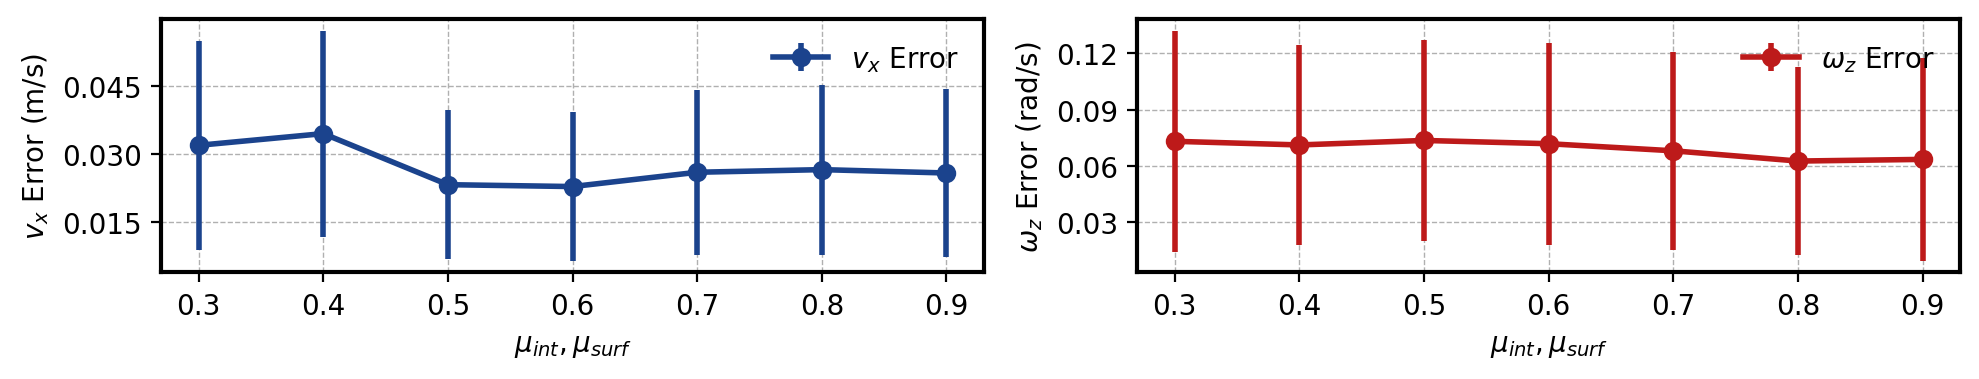

In [61]:
# error_file_path = data_dir / "g1_tracking_error.pkl"
# plot_save_path = "g1_tracking_perf.pdf"

error_file_path = data_dir / "t1_tracking_error.pkl"
plot_save_path = "t1_tracking_perf.pdf"

with open(error_file_path, "rb") as f:
    tracking_error_data = pickle.load(f)

muints = sorted(tracking_error_data.keys())
vx_err_mean = [tracking_error_data[muint]["vx"][0] for muint in muints]
vx_err_std = [tracking_error_data[muint]["vx"][1] for muint in muints]
wz_err_mean = [tracking_error_data[muint]["wz"][0] for muint in muints]
wz_err_std = [tracking_error_data[muint]["wz"][1] for muint in muints]
# mu_range = slice(None)
mu_range = slice(0, -1)

fig, ax = plt.subplots(1, 2, figsize=(10, 2))

# Plot
ax[0].errorbar(muints[mu_range], vx_err_mean[mu_range], yerr=vx_err_std[mu_range],
               fmt='-o', label=r"$v_x$ Error", color="#1B438D")
ax[1].errorbar(muints[mu_range], wz_err_mean[mu_range], yerr=wz_err_std[mu_range],
               fmt='-o', label=r"$\omega_z$ Error", color="#BD1A1A")

# === CREATE CUSTOM LABELS ===
# Convert your numeric keys to sorted floats
tick_positions = sorted(muints[mu_range])

# Build labels: last one becomes "R"
tick_labels = [f"{v:.1f}" for v in tick_positions]
# tick_labels[-1] = "R"

# Apply to both subplots
for a in ax: 
    a.set_xticks(tick_positions)
    a.set_xticklabels(tick_labels)
    a.set_xlabel("$\mu_{int}, \mu_{surf}$")
    a.yaxis.set_major_locator(plt.MaxNLocator(5))
    
ax[0].set_ylabel(r"$v_x$ Error $\mathrm{(m/s)}$")
ax[0].legend(frameon=False)
ax[0].grid(visible=True, which='both', linestyle='--', linewidth=0.5)

ax[1].set_ylabel(r"$\omega_z$ Error $\mathrm{(rad/s)}$")
ax[1].legend(frameon=False)
ax[1].grid(visible=True, which='both', linestyle='--', linewidth=0.5)

fig.tight_layout()
# plt.savefig(plot_save_path)
plt.show()


### contact force

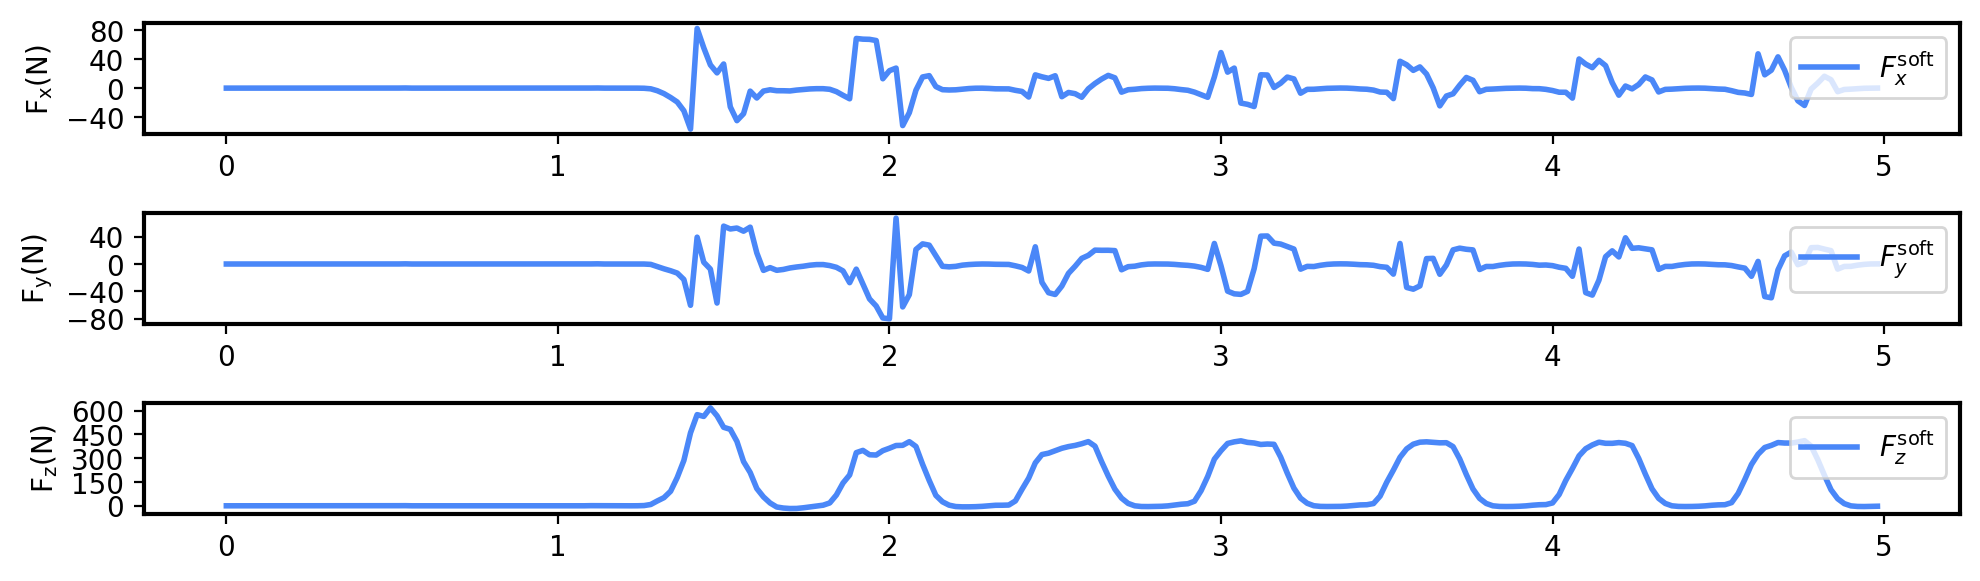

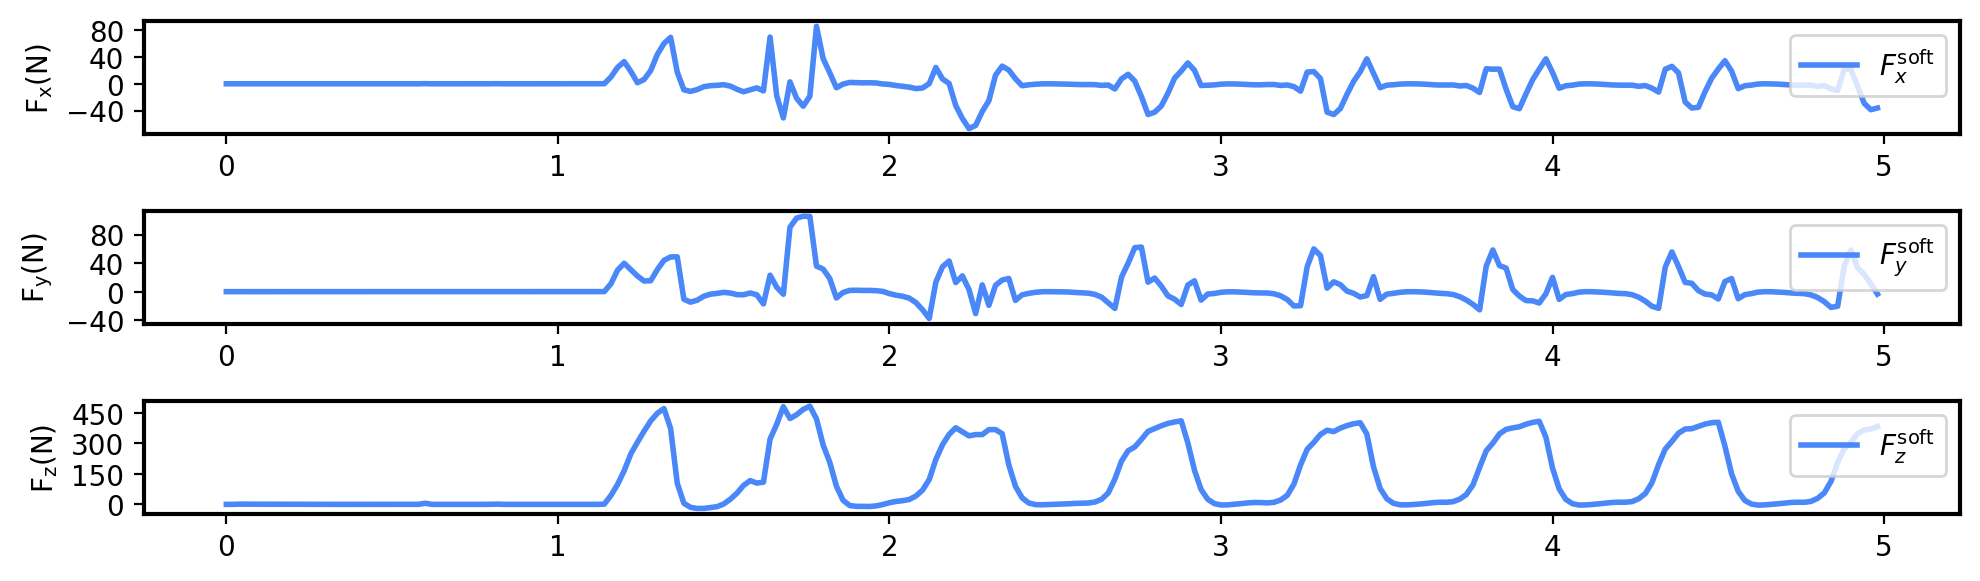

In [ ]:
ENV_ID = 0
t = 1/50 * np.arange(0, 1000)
# t_range = slice(None)
t_range = slice(0, 250)

# plot colors
colors = ["#1B438D", "#4A87F8"]

# left force
fig, axs = plt.subplots(3, 1, figsize=(10, 3))
axs[0].plot(t[t_range], data["left_force"][ENV_ID, t_range, 0], label=r"$F_x^\text{soft}$", color=colors[1])
# axs[0].plot(t[t_range], hard_contact_data["left_force"][ENV_ID, t_range, 0], label=r"$F_x^\text{hard}$", color=colors[0])
axs[0].legend(loc="upper right")
axs[0].set_ylabel(r"$\mathrm{F_x} (\mathrm{N})$")
axs[0].yaxis.set_major_locator(plt.MaxNLocator(5))
# axs[0].set_ylim([-100, 250])

axs[1].plot(t[t_range], data["left_force"][ENV_ID, t_range, 1], label=r"$F_y^\text{soft}$", color=colors[1])
# axs[1].plot(t[t_range], hard_contact_data["left_force"][ENV_ID, t_range, 1], label=r"$F_y^\text{hard}$", color=colors[0])
axs[1].legend(loc="upper right")
axs[1].set_ylabel(r"$\mathrm{F_y} (\mathrm{N})$")
axs[1].yaxis.set_major_locator(plt.MaxNLocator(5))

axs[2].plot(t[t_range], data["left_force"][ENV_ID, t_range, 2], label=r"$F_z^\text{soft}$", color=colors[1])
# axs[2].plot(t[t_range], hard_contact_data["left_force"][ENV_ID, t_range, 2], label=r"$F_z^\text{hard}$", color=colors[0])
axs[2].legend(loc="upper right")
axs[2].set_ylabel(r"$\mathrm{F_z} (\mathrm{N})$")
axs[2].yaxis.set_major_locator(plt.MaxNLocator(5))

fig.tight_layout()
# plt.savefig("left_force.pdf")
plt.show()

# right force
fig, axs = plt.subplots(3, 1, figsize=(10, 3))
axs[0].plot(t[t_range], data["right_force"][ENV_ID, t_range, 0], label=r"$F_x^\text{soft}$", color=colors[1])
# axs[0].plot(t[t_range], hard_contact_data["right_force"][ENV_ID, t_range, 0], label=r"$F_x^\text{hard}$", color=colors[0])
axs[0].legend(loc="upper right")
axs[0].set_ylabel(r"$\mathrm{F_x} (\mathrm{N})$")
axs[0].yaxis.set_major_locator(plt.MaxNLocator(5))
# axs[0].set_ylim([-100, 250])

axs[1].plot(t[t_range], data["right_force"][ENV_ID, t_range, 1], label=r"$F_y^\text{soft}$", color=colors[1])
# axs[1].plot(t[t_range], hard_contact_data["right_force"][ENV_ID, t_range, 1], label=r"$F_y^\text{hard}$", color=colors[0])
axs[1].legend(loc="upper right")
axs[1].set_ylabel(r"$\mathrm{F_y} (\mathrm{N})$")
axs[1].yaxis.set_major_locator(plt.MaxNLocator(5))

axs[2].plot(t[t_range], data["right_force"][ENV_ID, t_range, 2], label=r"$F_z^\text{soft}$", color=colors[1])
# axs[2].plot(t[t_range], hard_contact_data["right_force"][ENV_ID, t_range, 2], label=r"$F_z^\text{hard}$", color=colors[0])
axs[2].legend(loc="upper right")
axs[2].set_ylabel(r"$\mathrm{F_z} (\mathrm{N})$")
axs[2].yaxis.set_major_locator(plt.MaxNLocator(5))

fig.tight_layout()
# plt.savefig("right_force.pdf")
plt.show()

### foot position

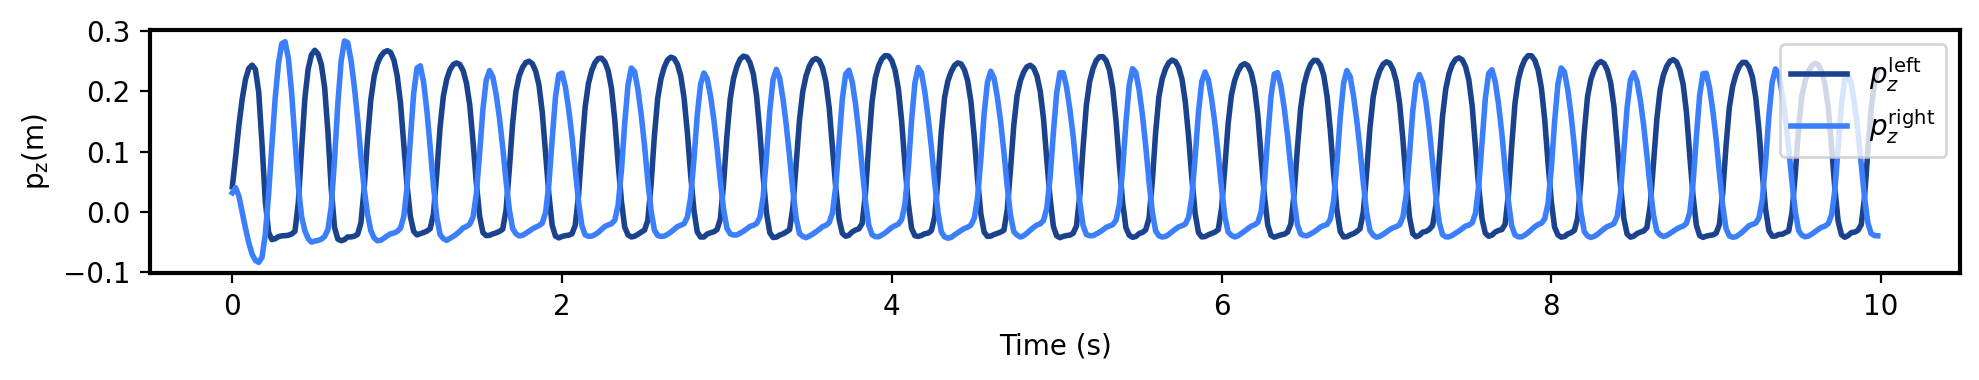

In [ ]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 500)
colors = ["#1B438D", "#3C7FFD"]


fig, axs = plt.subplots(1, 1, figsize=(10, 2))

# vx
axs.plot(t[t_range], data["left_foot_pos"][ENV_ID, t_range, 2], label=r"$p_z^\text{left}$", color=colors[0])
axs.plot(t[t_range], data["right_foot_pos"][ENV_ID, t_range, 2], label=r"$p_z^\text{right}$", color=colors[1])
axs.legend(loc="upper right")
axs.set_xlabel("Time (s)")
axs.set_ylabel(r"$\mathrm{p_z} (\mathrm{m})$")

axs.yaxis.set_major_locator(plt.MaxNLocator(5))

fig.tight_layout()
# plt.savefig("foot_pos.pdf")
plt.show()